In [17]:
import numpy as np
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical


In [19]:
X = np.load("../X_data.npy")
y = np.load("../y_user.npy")

print("Normalization öncesi:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

X_normalized = []

for sample in X:

    sample_mean = np.mean(sample)
    sample_std = np.std(sample)

    sample = (
        sample - sample_mean
    ) / (sample_std + 1e-8)

    X_normalized.append(sample)

X = np.array(X_normalized)

print("Shape:", X.shape)

print("Mean:", np.mean(X))
print("Std:", np.std(X))
print("\nNormalization sonrası:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

Normalization öncesi:
Min: -128.0
Max: 1010.0
Mean: 0.10079839
Std: 21.729828
Shape: (857, 100, 64)
Mean: 1.794399e-10
Std: 1.0

Normalization sonrası:
Min: -6.220304
Max: 40.37366
Mean: 1.794399e-10
Std: 1.0


In [20]:
user_names = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya",
    4: "empty"
}

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# Gaussian Noise
noise = np.random.normal(
    0,
    0.02,
    X_train.shape
)

X_noise = X_train + noise


# Temporal Shift
def temporal_shift(sample, shift=5):
    return np.roll(sample, shift, axis=0)

X_shifted = np.array([
    temporal_shift(
        x,
        shift=np.random.randint(-5,5)
    )
    for x in X_train
])


# Combine
X_train_final = np.concatenate([
    X_train,
    X_noise,
    X_shifted
], axis=0)

y_train_final = np.concatenate([
    y_train,
    y_train,
    y_train
], axis=0)

In [23]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(
    y_train_final,
    num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes
)

print(y_train_cat.shape)

(2055, 5)


In [24]:
model = Sequential([

    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/home/aleynagul/csi-gesture-identity-recognition/csi_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
history = model.fit(
    X_train_final,
    y_train_cat,

    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=25,
    batch_size=32,
    shuffle=True
)

Epoch 1/25
 4/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9870 - loss: 0.0328

W0000 00:00:1779623107.316760  208684 cpu_allocator_impl.cc:82] Allocation of 52608000 exceeds 10% of free system memory.


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9869 - loss: 0.0451 - val_accuracy: 0.7907 - val_loss: 0.8960
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9981 - loss: 0.0122 - val_accuracy: 0.8198 - val_loss: 0.7510
Epoch 3/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 0.8081 - val_loss: 0.8969
Epoch 4/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9995 - loss: 0.0050 - val_accuracy: 0.7965 - val_loss: 0.9591
Epoch 5/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9995 - loss: 0.0044 - val_accuracy: 0.8081 - val_loss: 0.9439
Epoch 6/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8140 - val_loss: 1.0041
Epoch 7/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.8081 - val_loss: 0.9406
Epoch 8/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8140 - val_loss: 1.

In [26]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("Final Test Accuracy:", acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7907 - loss: 0.9361
Final Test Accuracy: 0.7906976938247681


In [27]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    pred_classes
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        58
           1       0.79      0.86      0.83        36
           2       0.88      0.61      0.72        36
           3       0.74      0.94      0.83        36
           4       0.60      1.00      0.75         6

    accuracy                           0.79       172
   macro avg       0.77      0.83      0.78       172
weighted avg       0.81      0.79      0.79       172



In [42]:
import random

idx = random.randint(0, len(X_test)-1)

test_sample = X_test[idx]
true_user_id = y_test[idx]

sample_input = np.expand_dims(test_sample, axis=0)

prediction = model.predict(sample_input)

predicted_user_id = np.argmax(prediction)

id_to_user = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya",
    4: "empty"
}

print("------ CSI USER TEST DEMO ------")
print(f"Gerçek Kullanıcı : {id_to_user.get(true_user_id)}")
print(f"Tahmin Edilen    : {id_to_user.get(predicted_user_id)}")

confidence = np.max(prediction) * 100

print(f"Güven Skoru      : %{confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
------ CSI USER TEST DEMO ------
Gerçek Kullanıcı : aleyna
Tahmin Edilen    : aleyna
Güven Skoru      : %99.98


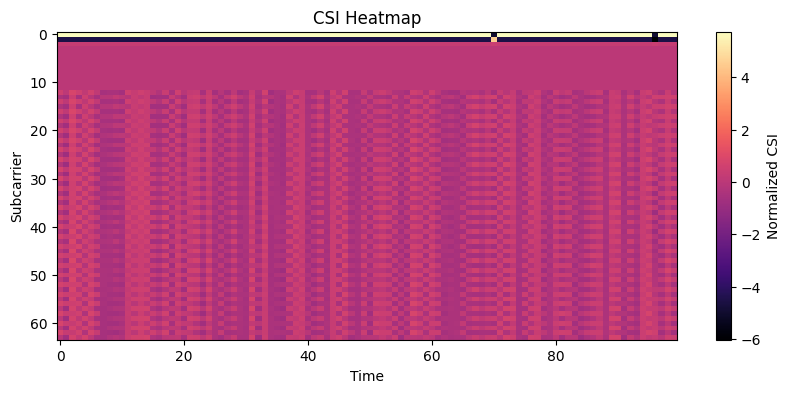

In [43]:
plt.figure(figsize=(10,4))

plt.imshow(test_sample.T,
           aspect='auto',
           cmap='magma')

plt.title("CSI Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar(label="Normalized CSI")

plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


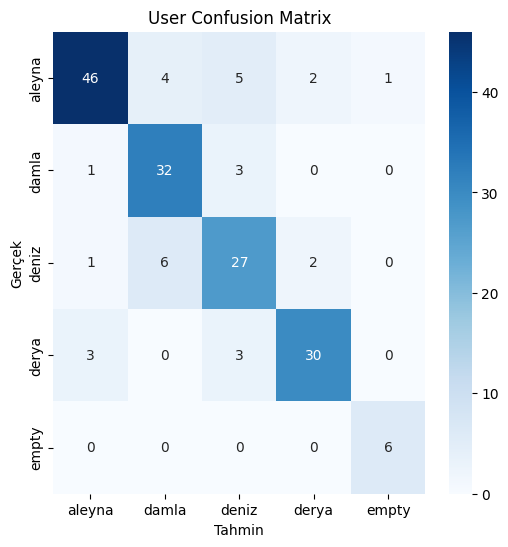

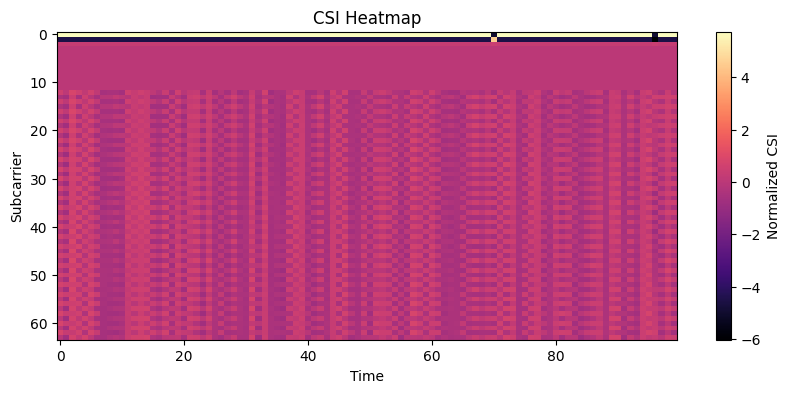

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(user_names.values()),
    yticklabels=list(user_names.values())
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("User Confusion Matrix")
plt.figure(figsize=(10,4))

plt.imshow(test_sample.T,
           aspect='auto',
           cmap='magma')

plt.title("CSI Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar(label="Normalized CSI")

plt.show()
plt.show()

In [45]:
model.save("../models/MULTI_SESSION_MODEL_EMPTY_V4.h5")